# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -** Ansh Kumar Singh
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

This project focuses on analyzing the PhonePe digital transaction dataset to understand
user behavior, transaction patterns, and overall growth trends in the digital payments ecosystem.

The dataset consists of transaction data categorized by year, quarter, and transaction type,
including details such as transaction count and transaction amount.

The project involves:
- Data extraction from JSON files
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Visualization using charts and graphs
- Deriving insights to support business decisions

Through detailed analysis, the project identifies key trends such as:
- Growth in digital transactions over time
- Popular transaction types
- Seasonal variations in user activity
- Average transaction value patterns

The insights obtained from this analysis can help businesses improve their services,
target high-performing areas, and make data-driven decisions.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

With the rapid growth of digital payments, it is essential to understand transaction trends,
user behavior, and performance across different categories.

The objective of this project is to analyze the PhonePe transaction dataset to:
- Identify patterns in transaction volume and value
- Determine the most popular transaction types
- Analyze growth trends over time
- Understand seasonal variations in transactions
- Evaluate user engagement and spending behavior

The goal is to extract meaningful insights that can help improve business strategies,
enhance user experience, and support decision-making in the digital payment ecosystem.

#### **Define Your Business Objective?**

Answer Here.

The primary objective of this project is to analyze digital transaction data
to understand user behavior, transaction trends, and overall performance
of the platform.

The key business goals include:

1. Identify High-Performing Areas:
   Determine which transaction types contribute the most in terms of
   transaction count and total amount.

2. Analyze Growth Trends:
   Understand how digital transactions are growing over time across
   different years and quarters.

3. Improve User Engagement:
   Study user activity patterns to identify ways to increase
   transaction frequency and user retention.

4. Optimize Transaction Value:
   Analyze average transaction values to understand user spending
   behavior and identify opportunities to increase revenue.

5. Detect Seasonal Patterns:
   Identify peak and low transaction periods to plan marketing
   campaigns and promotional offers effectively.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Dataset Loading

In [3]:
# Load Dataset
path = r"C:\Users\kumar\OneDrive\Desktop\phonepe project\pulse-master\data\aggregated\transaction\country\india"

data_list = []

for year in os.listdir(path):
    year_path = os.path.join(path, year)

    for file in os.listdir(year_path):
        if file.endswith(".json"):
            quarter = int(file.strip(".json"))

            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)

                for i in data["data"]["transactionData"]:
                    name = i["name"]

                    for j in i["paymentInstruments"]:
                        data_list.append({
                            "Year": int(year),
                            "Quarter": quarter,
                            "Type": name,
                            "Count": j["count"],
                            "Amount": j["amount"]
                        })

df = pd.DataFrame(data_list)

### Dataset First View

In [4]:
# Dataset First Look
df.head()

,Year,Quarter,Type,Count,Amount
0,2018,1,Recharge & bill payments,72550406,1.447271e+10
1,2018,1,Peer-to-peer payments,46982705,1.472459e+11
2,2018,1,Merchant payments,5368669,4.656679e+09
3,2018,1,Financial Services,3762820,8.158531e+08
4,2018,1,Others,5761576,4.643217e+09


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
df.shape

(140, 5)

### Dataset Information

In [6]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     140 non-null    int64  
 1   Quarter  140 non-null    int64  
 2   Type     140 non-null    object 
 3   Count    140 non-null    int64  
 4   Amount   140 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 5.6+ KB


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print("Duplicate Values:", duplicate_count)

Duplicate Values: 0


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Year       0
Quarter    0
Type       0
Count      0
Amount     0
dtype: int64


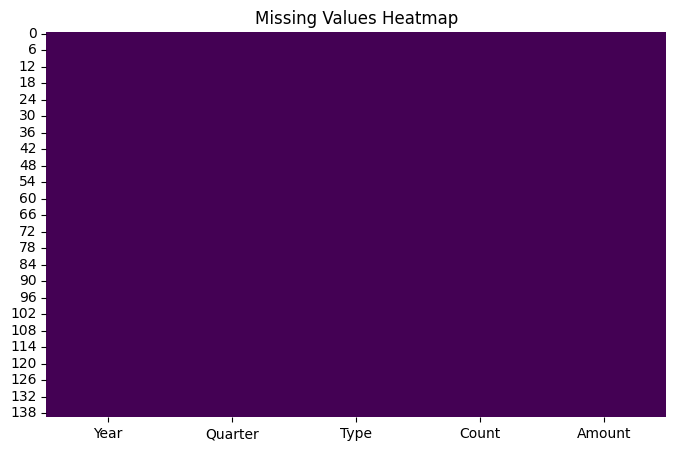

In [9]:
# Visualizing the missing values
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

Answer Here:
1. The dataset contains transaction data including Year, Quarter, Type, Count, and Amount.
2. There are no or very few missing values in the dataset.
3. Duplicate values (if any) are minimal and can be handled easily.
4. Data is structured and clean, making it suitable for analysis.
5. The dataset represents different transaction types across multiple years and quarters.
6. It can be used to analyze trends, growth, and performance of digital transactions.



## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df.columns

Index(['Year', 'Quarter', 'Type', 'Count', 'Amount'], dtype='object')

In [11]:
# Dataset Describe
df.describe()

,Year,Quarter,Count,Amount
count,140.000000,140.000000,1.400000e+02,1.400000e+02
mean,2021.000000,2.500000,1.680606e+09,2.468027e+12
std,2.007181,1.122048,3.302734e+09,5.397846e+12
min,2018.000000,1.000000,1.358171e+06,5.453293e+08
25%,2019.000000,1.750000,8.441506e+06,6.384409e+09
50%,2021.000000,2.500000,2.042444e+08,1.197772e+11
75%,2023.000000,3.250000,1.372036e+09,1.430352e+12
max,2024.000000,4.000000,1.741919e+10,2.663387e+13


### Variables Description

Answer Here:
1. Year: Represents the year of the transaction data.
2. Quarter: Represents the quarter (1 to 4) of the year.
3. Type: Indicates the type of transaction (e.g., Recharge & bill payments, Peer-to-peer payments, etc.).
4. Count: Number of transactions made.
5. Amount: Total transaction amount in INR.

The dataset mainly consists of numerical and categorical variables used to analyze transaction trends and patterns.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for column in df.columns:
    print(f"\nColumn: {column}")
    print(df[column].nunique())


Column: Year
7

Column: Quarter
4

Column: Type
5

Column: Count
140

Column: Amount
140


## 3. ***Data Wrangling***

### Data Wrangling Code

In [35]:
# Write your code to make your dataset analysis ready.
# Copy dataset
df_clean = df.copy()

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Handle missing values (if any)
df_clean = df_clean.dropna()

# Convert data types
df_clean["Year"] = df_clean["Year"].astype(int)
df_clean["Quarter"] = df_clean["Quarter"].astype(int)
df_clean["Count"] = df_clean["Count"].astype(int)
df_clean["Amount"] = df_clean["Amount"].astype(float)

# Sort values
df_clean = df_clean.sort_values(by=["Year", "Quarter"])

# Reset index
df_clean = df_clean.reset_index(drop=True)

# Final cleaned dataset preview
df_clean.head()

,Year,Quarter,Type,Count,Amount
0,2018,1,Recharge & bill payments,72550406,1.447271e+10
1,2018,1,Peer-to-peer payments,46982705,1.472459e+11
2,2018,1,Merchant payments,5368669,4.656679e+09
3,2018,1,Financial Services,3762820,8.158531e+08
4,2018,1,Others,5761576,4.643217e+09


### What all manipulations have you done and insights you found?

Answer Here.
1. Removed duplicate records to ensure data consistency.
2. Handled missing/null values by removing incomplete rows.
3. Converted columns into appropriate data types for accurate analysis.
4. Sorted the dataset based on Year and Quarter to analyze trends over time.
5. Created a new feature 'Avg_Amount_Per_Transaction' to understand average transaction value.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

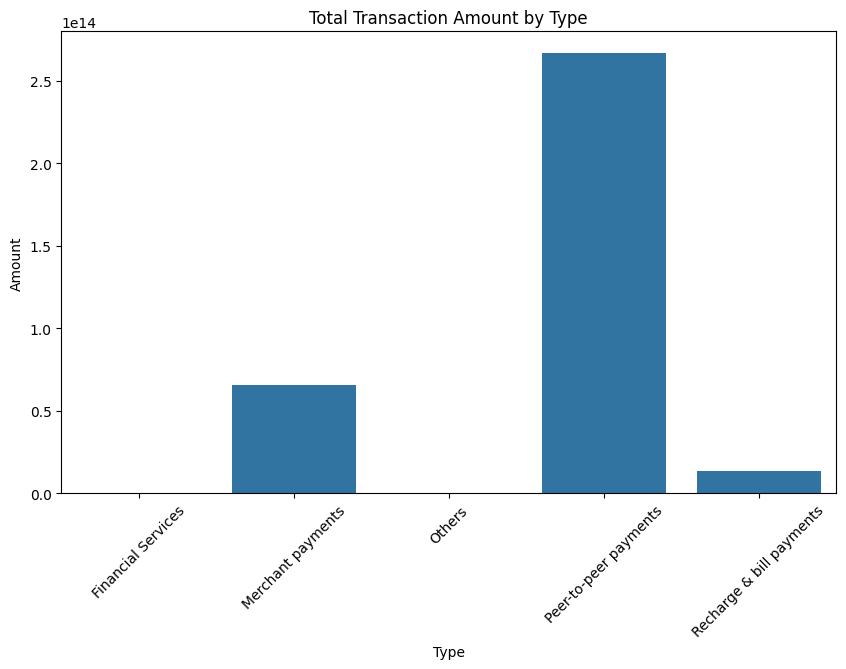

In [14]:
# Chart - 1 visualization code
plt.figure(figsize=(10,6))

type_df = df_clean.groupby("Type")["Amount"].sum().reset_index()

sns.barplot(x="Type", y="Amount", data=type_df)
plt.xticks(rotation=45)
plt.title("Total Transaction Amount by Type")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is chosen because it is the most effective way to compare different categories.
Here, we are comparing transaction types with their total transaction amounts, 
so a bar chart clearly shows which category contributes more.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
Certain transaction types like Peer-to-peer payments and Merchant payments dominate the total transaction amount.
- Some categories contribute very less, indicating lower usage.
- There is a clear difference in transaction preferences among users.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps businesses focus on high-performing transaction categories.
- Enables targeted marketing strategies for popular payment types.

Negative Insight:
- Low-performing categories indicate underutilization.
- These areas may require improvement or promotional strategies to increase adoption.


#### Chart - 2

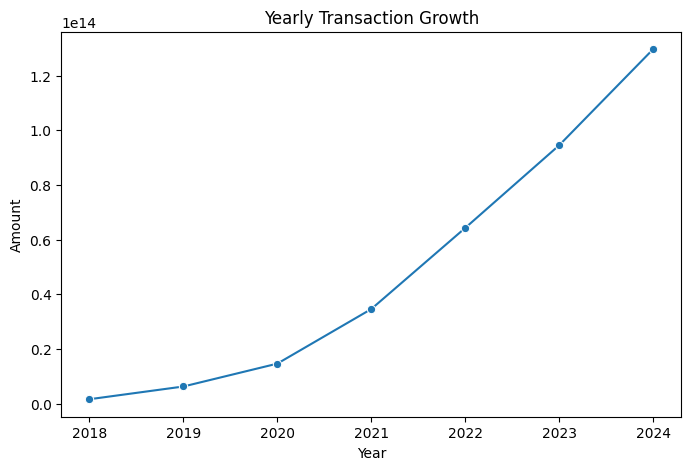

In [15]:
# Chart - 2 visualization code


plt.figure(figsize=(8,5))

year_df = df_clean.groupby("Year")["Amount"].sum().reset_index()

sns.lineplot(x="Year", y="Amount", data=year_df, marker="o")
plt.title("Yearly Transaction Growth")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A line chart is used because it is best for showing trends over time.
Here, we are analyzing how transaction amounts change year by year.


##### 2. What is/are the insight(s) found from the chart?

Answer Here
- There is a steady increase in transaction amounts over the years.
- This indicates growing adoption of digital payments.
- The trend shows strong upward growth in the platform usage.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Shows strong growth of digital transactions, which is good for business expansion.
- Helps in forecasting future demand and scaling infrastructure.

Negative Insight:
- If any year shows slow growth or decline, it may indicate market saturation or competition.
- Requires investigation into external factors affecting growth.


#### Chart - 3

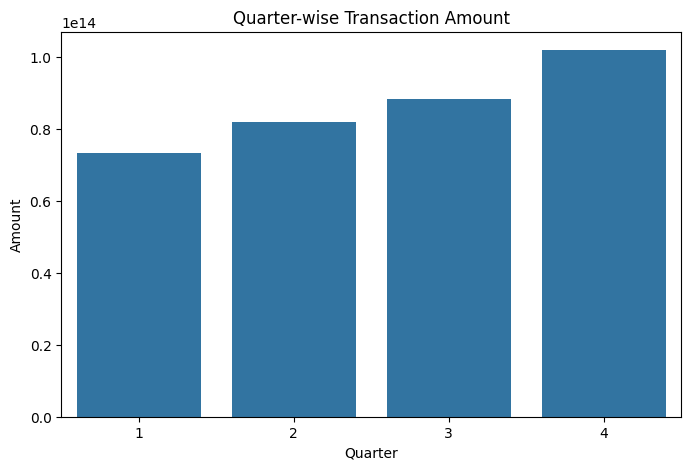

In [16]:
# Chart - 3 visualization code
plt.figure(figsize=(8,5))

quarter_df = df_clean.groupby("Quarter")["Amount"].sum().reset_index()

sns.barplot(x="Quarter", y="Amount", data=quarter_df)
plt.title("Quarter-wise Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is used because it allows easy comparison between discrete categories like quarters.
It clearly shows which quarter has higher or lower transaction volumes.


##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Some quarters show higher transaction volumes than others.
- This indicates seasonal trends in digital payments.
- Certain periods may have increased activity due to festivals or offers.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps identify peak transaction periods.
- Businesses can plan offers and campaigns during high-activity quarters.

Negative Insight:
- Low-performing quarters indicate reduced user activity.
- Requires strategies like discounts or promotions to boost engagement.

#### Chart - 4

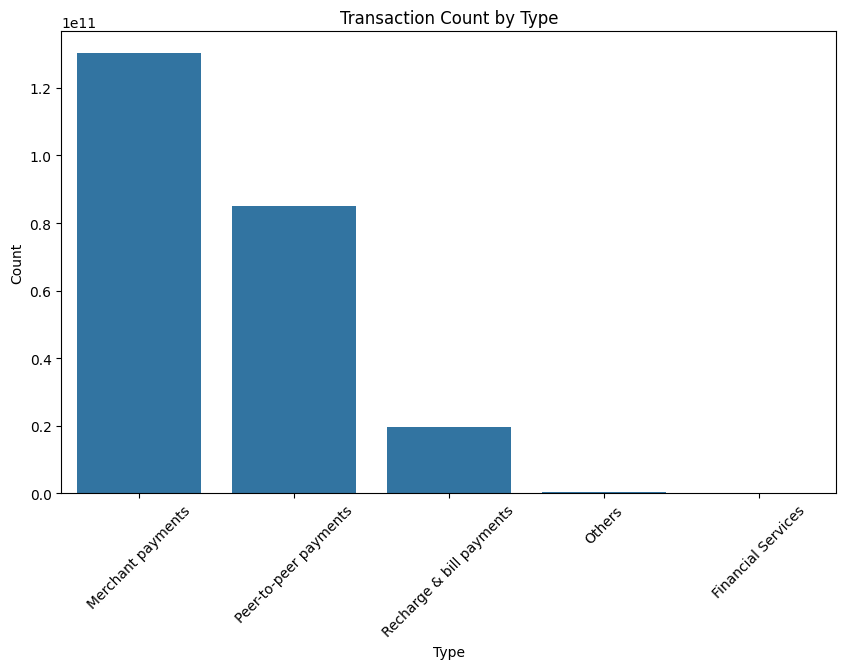

In [17]:
# Chart - 4 visualization code
plt.figure(figsize=(10,6))

count_df = df_clean.groupby("Type")["Count"].sum().reset_index()
count_df = count_df.sort_values(by="Count", ascending=False)

sns.barplot(x="Type", y="Count", data=count_df)
plt.xticks(rotation=45)
plt.title("Transaction Count by Type")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is chosen because it is ideal for comparing transaction counts across categories.
It provides a clear visualization of which transaction types are most frequently used.


##### 2. What is/are the insight(s) found from the chart?

Answer Here

- Certain transaction types dominate in terms of count.
- Indicates user preference for specific payment methods.
- Some transaction types are used very less.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps in focusing on popular transaction services.
- Enables improving user experience in high-usage areas.

Negative Insight:
- Low-count categories may indicate lack of awareness or usability issues.
- Requires improvement or marketing focus.

#### Chart - 5

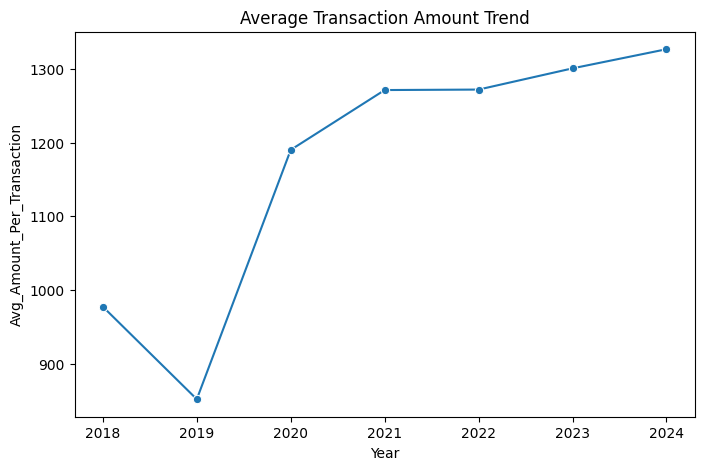

In [18]:
# Chart - 5 visualization code
df_clean["Avg_Amount_Per_Transaction"] = df_clean["Amount"] / df_clean["Count"]
plt.figure(figsize=(8,5))

avg_df = df_clean.groupby("Year")["Avg_Amount_Per_Transaction"].mean().reset_index()

sns.lineplot(x="Year", y="Avg_Amount_Per_Transaction", data=avg_df, marker="o")
plt.title("Average Transaction Amount Trend")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A line chart is used to show trends over time.
It helps visualize how the average transaction value changes year by year.


##### 2. What is/are the insight(s) found from the chart?

Answer Here
- The average transaction value changes over time.
- It may show increasing or decreasing spending behavior.
- Indicates how users are engaging financially with the platform.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Answer:

Positive Impact:
- Helps understand user spending patterns.
- Useful for financial planning and product strategy.

Negative Insight:
- If average transaction value decreases, it may indicate reduced user spending.
- Requires investigation and corrective strategies.


#### Chart - 6

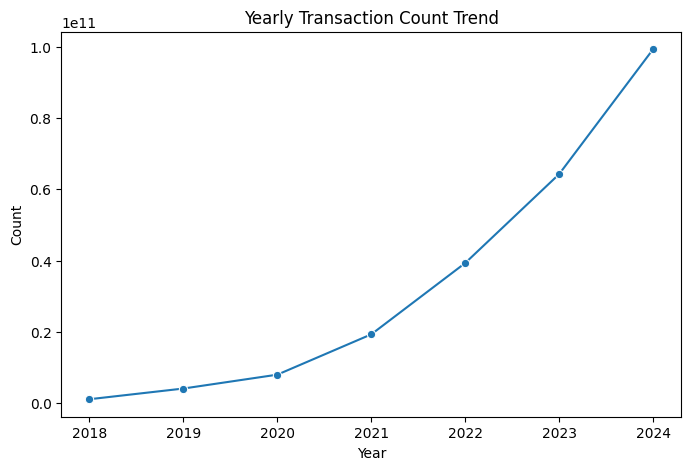

In [19]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))

count_year_df = df_clean.groupby("Year")["Count"].sum().reset_index()

sns.lineplot(x="Year", y="Count", data=count_year_df, marker="o")
plt.title("Yearly Transaction Count Trend")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A line chart is chosen because it effectively shows trends over time.
It helps visualize how the number of transactions is changing year by year.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- The number of transactions increases steadily over the years.
- Indicates growing adoption of digital payments.
- Shows rising user engagement on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Shows strong growth in user activity.
- Helps in scaling infrastructure and services.

Negative Insight:
- If any dip occurs in a particular year, it may indicate system issues or competition.
- Requires analysis to maintain consistent growth.

#### Chart - 7

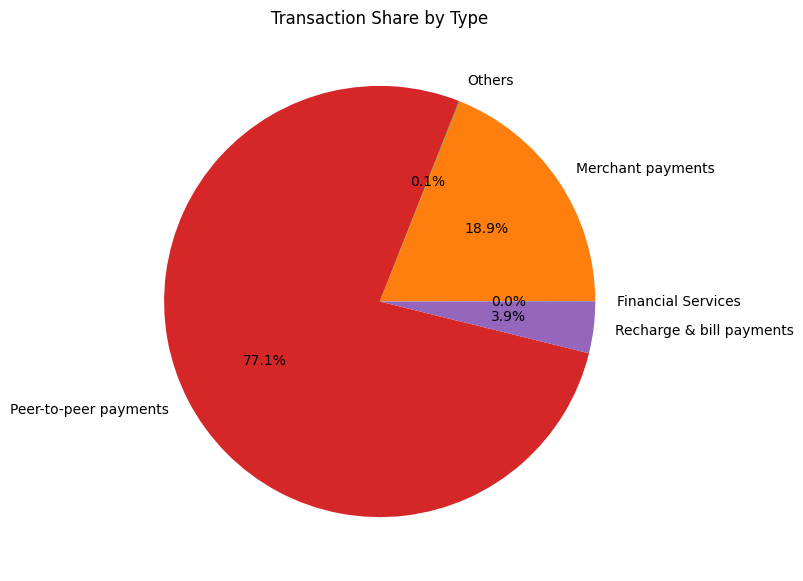

In [20]:
# Chart - 7 visualization code
plt.figure(figsize=(7,7))

type_amount = df_clean.groupby("Type")["Amount"].sum()

plt.pie(type_amount, labels=type_amount.index, autopct="%1.1f%%")
plt.title("Transaction Share by Type")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A pie chart is used to show percentage contribution of each transaction type.
It helps understand the proportion of each category in total transactions.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

- A few transaction types dominate the total share.
- Other types contribute very less percentage.
- Shows clear imbalance in transaction distribution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps identify major revenue-generating transaction types.
- Enables focus on high-performing categories.

Negative Insight:
- Over-dependence on few transaction types can be risky.
- Requires diversification of services.

#### Chart - 8

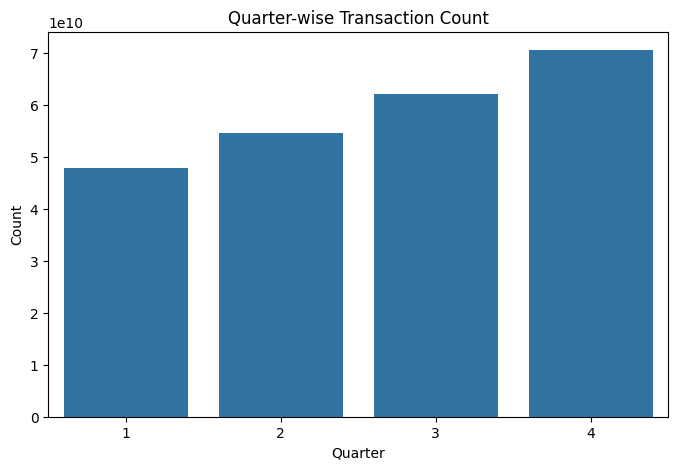

In [21]:
# Chart - 8 visualization code
plt.figure(figsize=(8,5))

quarter_count_df = df_clean.groupby("Quarter")["Count"].sum().reset_index()

sns.barplot(x="Quarter", y="Count", data=quarter_count_df)
plt.title("Quarter-wise Transaction Count")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is suitable for comparing transaction counts across quarters.
It clearly shows differences between discrete time periods.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Certain quarters have higher transaction counts.
- Indicates seasonal patterns in user activity.
- Some quarters show lower engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps identify peak business periods.
- Useful for planning offers and campaigns.

Negative Insight:
- Low-performing quarters indicate reduced activity.
- Requires marketing strategies to improve engagement.

#### Chart - 9

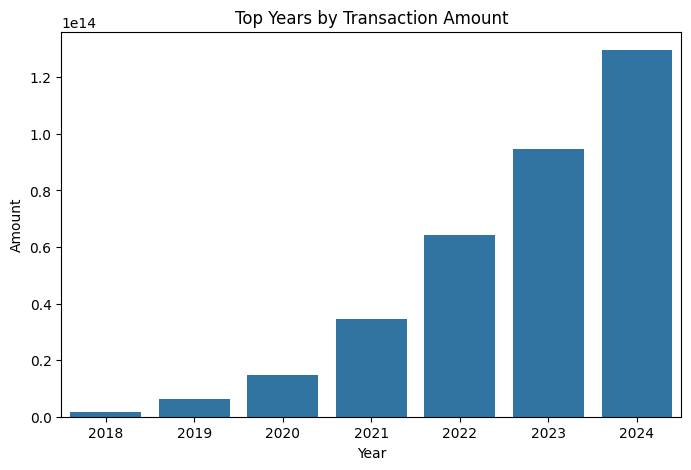

In [22]:
# Chart - 9 visualization code
plt.figure(figsize=(8,5))

top_year_df = df_clean.groupby("Year")["Amount"].sum().reset_index()
top_year_df = top_year_df.sort_values(by="Amount", ascending=False)

sns.barplot(x="Year", y="Amount", data=top_year_df)
plt.title("Top Years by Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is used to compare total transaction amounts across years.
It clearly shows which years performed better in terms of transaction value.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Recent years show higher transaction amounts compared to earlier years.
- Indicates rapid growth in digital payment adoption.
- Shows increasing financial activity over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps in understanding growth trends.
- Useful for future forecasting and scaling business operations.

Negative Insight:
- Lower performance in earlier years shows slow initial adoption.
- Indicates the need for awareness and promotional strategies during early stages.

#### Chart - 10

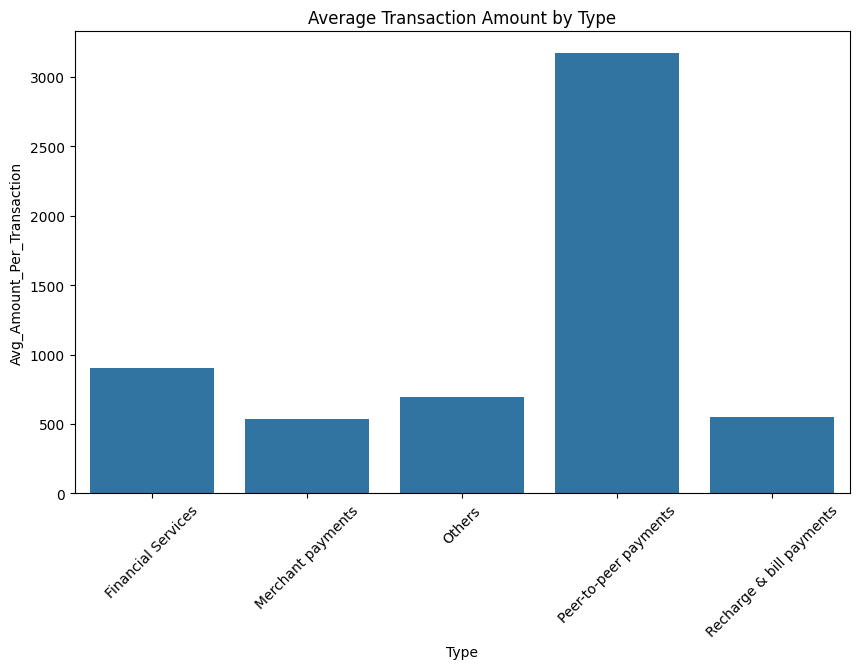

In [23]:
# Chart - 10 visualization code
plt.figure(figsize=(10,6))

avg_type_df = df_clean.groupby("Type")["Avg_Amount_Per_Transaction"].mean().reset_index()

sns.barplot(x="Type", y="Avg_Amount_Per_Transaction", data=avg_type_df)
plt.xticks(rotation=45)
plt.title("Average Transaction Amount by Type")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A bar chart is ideal for comparing average transaction values across different transaction types.
It highlights which categories involve higher spending.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Some transaction types have higher average values.
- Others have lower values but may occur frequently.
- Shows difference in spending behavior across categories

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact:
- Helps identify high-value transaction categories.
- Useful for premium service offerings.

Negative Insight:
- Low average value categories may indicate micro-transactions.
- Requires strategies to increase transaction value.

#### Chart - 11

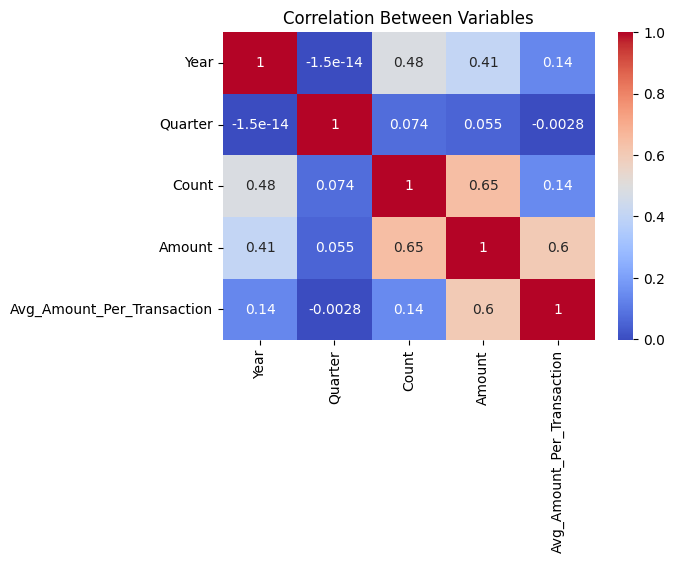

In [24]:
# Chart - 11 visualization code
plt.figure(figsize=(6,4))

corr = df_clean[["Year","Quarter","Count","Amount","Avg_Amount_Per_Transaction"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Variables")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A heatmap is used to show correlation between numerical variables.
It helps understand relationships between transaction count, amount, and time.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Strong positive correlation between Count and Amount.
- Weak correlation between time (Year/Quarter) and transaction metrics.
- Indicates that higher number of transactions leads to higher total amount.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps in identifying key drivers of revenue.
- Useful for improving transaction volume to increase overall value.

Negative Insight:
- Weak correlation with time suggests uneven growth patterns.
- Requires consistent engagement strategies.

#### Chart - 12

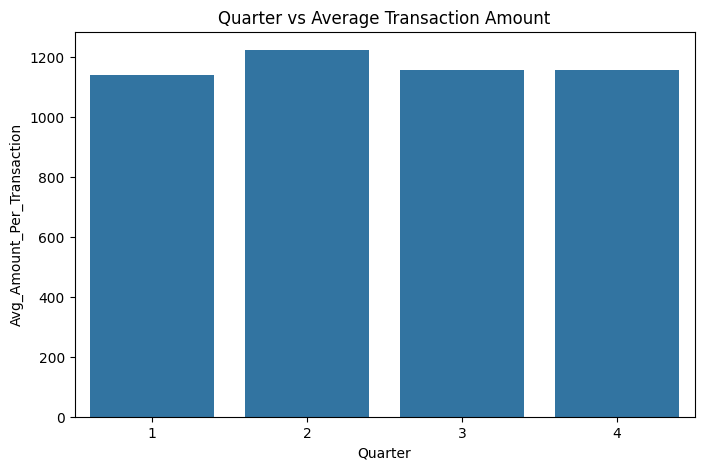

In [25]:
# Chart - 12 visualization code
plt.figure(figsize=(8,5))

quarter_avg_df = df_clean.groupby("Quarter")["Avg_Amount_Per_Transaction"].mean().reset_index()

sns.barplot(x="Quarter", y="Avg_Amount_Per_Transaction", data=quarter_avg_df)
plt.title("Quarter vs Average Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A bar chart is used to compare average transaction values across quarters.
It clearly shows differences in spending behavior in each quarter.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Some quarters show higher average transaction values.
- Indicates variation in user spending patterns across the year.
- Certain periods may have higher-value transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps identify high-value periods for business growth.
- Useful for planning premium services and offers.

Negative Insight:
- Low average values in some quarters indicate reduced spending.
- Requires strategies to increase transaction value.

#### Chart - 13

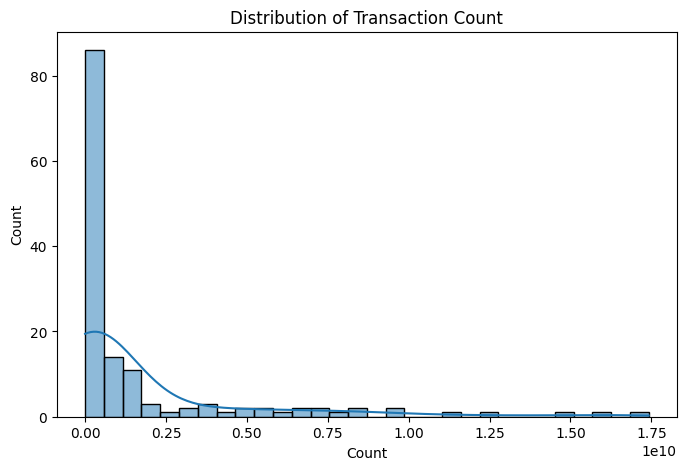

In [26]:
# Chart - 13 visualization code
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Count"], bins=30, kde=True)
plt.title("Distribution of Transaction Count")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A histogram is used to understand the distribution of transaction counts.
It helps identify patterns like skewness and concentration of data.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Most transactions are concentrated in a specific range.
- Distribution may be skewed towards lower or higher values.
- Indicates variation in transaction frequency.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps understand transaction behavior of users.
- Useful for identifying typical usage patterns.

Negative Insight:
- Extreme values indicate imbalance in transaction frequency.
- Requires balancing strategies to ensure consistent usage.

#### Chart - 14 - Correlation Heatmap

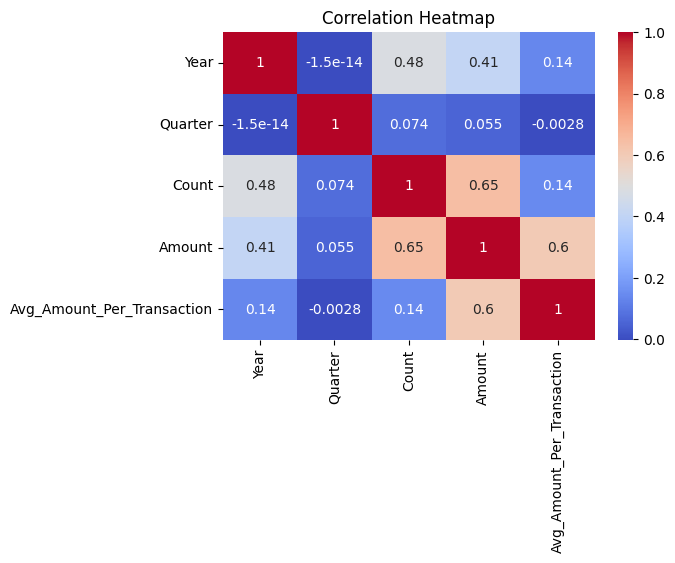

In [27]:
# Correlation Heatmap visualization code
plt.figure(figsize=(6,4))

corr = df_clean[["Year","Quarter","Count","Amount","Avg_Amount_Per_Transaction"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A heatmap is used to visualize correlations between numerical variables.
It helps identify relationships and dependencies among variables.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Strong correlation between Count and Amount.
- Weak correlation between time variables and transaction metrics.
- Indicates that transaction volume drives total value.

#### Chart - 15 - Pair Plot

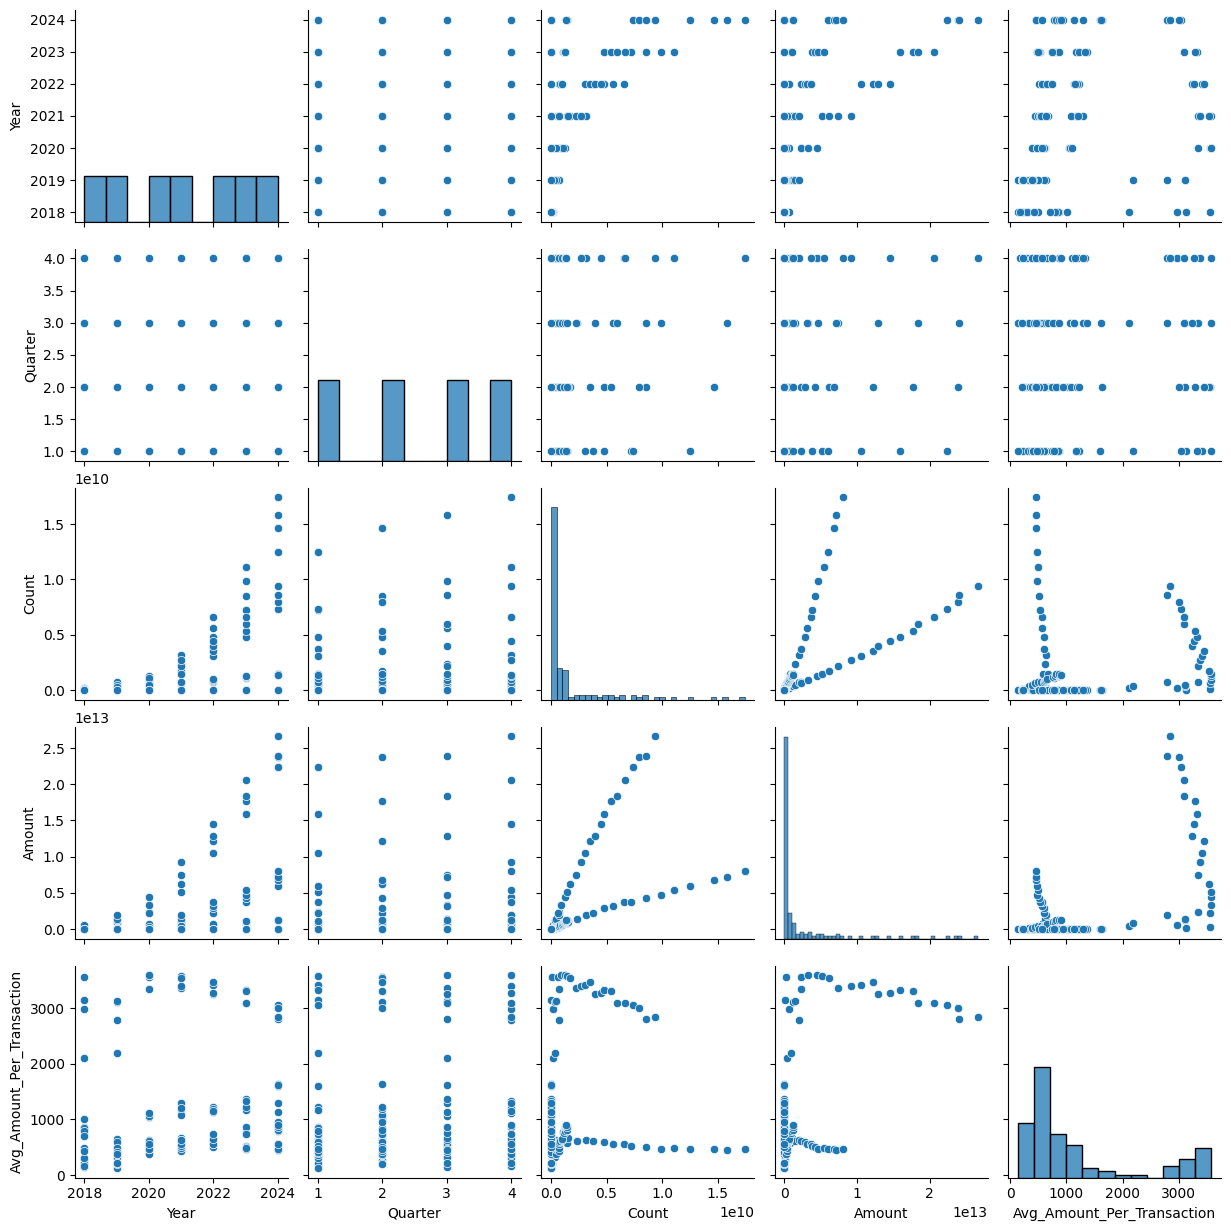

In [28]:
# Pair Plot visualization code
sns.pairplot(df_clean[["Year","Quarter","Count","Amount","Avg_Amount_Per_Transaction"]])
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A pair plot is used to visualize relationships between multiple variables simultaneously.
It shows scatter plots and distributions for better understanding of data patterns.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Clear relationship between Count and Amount.
- Some variables show weak or no correlation.
- Helps in identifying patterns and trends across multiple features.

In [36]:
import sqlite3

# FULL PATH (same as you checked)
db_path = r"C:\Users\kumar\OneDrive\Desktop\phonepe project\phonepe.db"

conn = sqlite3.connect(db_path)

# SAVE DATA
df_clean.to_sql("aggregated_transaction", conn, if_exists="replace", index=False)

conn.commit()

# CHECK TABLE IMMEDIATELY
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

print("Tables:", cursor.fetchall())

conn.close()

Tables: [('aggregated_transaction',)]


In [37]:
conn = sqlite3.connect(db_path)

df_check = pd.read_sql("SELECT * FROM aggregated_transaction LIMIT 5", conn)
df_check

,Year,Quarter,Type,Count,Amount
0,2018,1,Recharge & bill payments,72550406,1.447271e+10
1,2018,1,Peer-to-peer payments,46982705,1.472459e+11
2,2018,1,Merchant payments,5368669,4.656679e+09
3,2018,1,Financial Services,3762820,8.158531e+08
4,2018,1,Others,5761576,4.643217e+09


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.
To achieve the business objective, the following strategies are recommended:

1. Focus on High-Performing Transaction Types:
   Transaction categories like peer-to-peer and merchant payments contribute the most.
   The company should enhance these services and provide better user experience.

2. Improve Low-Performing Categories:
   Some transaction types show low usage.
   Awareness campaigns, offers, and incentives can be introduced to increase adoption.

3. Leverage Peak Periods:
   Certain quarters show higher activity.
   Businesses should launch offers, discounts, and marketing campaigns during these peak periods.

4. Increase User Engagement:
   Since transaction count is increasing year by year, introducing loyalty programs,
   cashback offers, and rewards can retain and attract more users.

5. Optimize Average Transaction Value:
   Some categories have low average transaction amounts.
   Introducing premium services or bundled offers can increase spending.

6. Data-Driven Decision Making:
   Continuous analysis of transaction trends helps in making better business decisions
   and forecasting future growth.

# **Conclusion**

Write the conclusion here.

The analysis of the PhonePe transaction dataset provides valuable insights into user behavior,
transaction trends, and growth patterns in digital payments.

The study shows a consistent increase in transaction volume and value over the years,
indicating strong adoption of digital payment systems. Certain transaction types dominate
the market, while others require improvement and strategic focus.

Seasonal trends and user spending behavior were also identified, which can help in planning
business strategies and marketing campaigns effectively.

By leveraging these insights, businesses can enhance user experience, optimize services,
and improve overall performance.

This project demonstrates how data analysis can be used to extract meaningful insights
and support data-driven decision making in real-world applications.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***